# Notebook 1: Exploratory Data Analysis & Preprocessing
## Hyperspectral Data Science for Corn

**Objectives:**
- Load and explore the hyperspectral corn dataset
- Analyze data quality (missing values, duplicates, outliers)
- Visualize spectral characteristics
- Preprocess and normalize data
- Split and save train/test datasets

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Dataset

In [2]:
# Load the corn hyperspectral dataset
df = pd.read_excel('../data/Corn_dataset.xlsx')
print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,hsi_id,0,1,2,3,4,5,6,7,8,...,439,440,441,442,443,444,445,446,447,vomitoxin_ppb
0,imagoai_corn_0,0.416181,0.396844,0.408985,0.372865,0.385293,0.365390,0.355226,0.343350,0.344837,...,0.710280,0.717482,0.715078,0.705379,0.696691,0.692793,0.711369,0.697679,0.704520,1100
1,imagoai_corn_1,0.415797,0.402956,0.402564,0.396014,0.397192,0.389634,0.375671,0.363689,0.373883,...,0.684011,0.697271,0.701995,0.696077,0.701012,0.677418,0.696921,0.696544,0.689054,1000
2,imagoai_corn_2,0.389023,0.371206,0.373098,0.373872,0.361056,0.349709,0.333882,0.330841,0.328925,...,0.683054,0.669286,0.663179,0.676165,0.676591,0.655951,0.658945,0.670989,0.665176,1300
3,imagoai_corn_3,0.468837,0.473255,0.462949,0.459335,0.461672,0.459824,0.458194,0.427737,0.415360,...,0.742782,0.730801,0.736787,0.730044,0.751437,0.738497,0.742446,0.754657,0.733474,1300
4,imagoai_corn_4,0.483352,0.487274,0.469153,0.487648,0.464026,0.451152,0.458229,0.440782,0.426193,...,0.770227,0.773013,0.761431,0.763488,0.762473,0.744012,0.775486,0.760431,0.751988,220


## 2. Dataset Overview

In [3]:
# Shape and basic info
print(f"Dataset Shape: {df.shape}")
print(f"Number of Samples: {df.shape[0]}")
print(f"Number of Features: {df.shape[1]}")
print(f"\nColumn Names:\n{df.columns.tolist()}")

Dataset Shape: (500, 450)
Number of Samples: 500
Number of Features: 450

Column Names:
['hsi_id', 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 2

In [4]:
# Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Columns: 450 entries, hsi_id to vomitoxin_ppb
dtypes: float64(448), int64(1), object(1)
memory usage: 1.7+ MB


## 3. Data Quality Analysis

In [5]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    print("Missing Values Found:")
    print(missing_df)
else:
    print("✓ No missing values found!")

✓ No missing values found!


In [6]:
# Duplicate analysis
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")

Number of duplicate rows: 0


## 4. Statistical Summary

In [7]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
0,500.0,0.443118,0.044719,0.311182,0.410456,0.449105,0.480245,0.556287
1,500.0,0.440761,0.045520,0.295321,0.404310,0.442651,0.478822,0.530168
2,500.0,0.433814,0.045764,0.284064,0.397038,0.434215,0.473158,0.528774
3,500.0,0.426122,0.046070,0.282054,0.389029,0.425074,0.464947,0.533202
4,500.0,0.418990,0.045405,0.296702,0.382102,0.417075,0.459232,0.511909
...,...,...,...,...,...,...,...,...
444,500.0,0.738738,0.053601,0.571767,0.700638,0.743965,0.775686,0.945225
445,500.0,0.738298,0.054014,0.577803,0.698655,0.743301,0.775621,0.932812
446,500.0,0.737599,0.054136,0.576985,0.698107,0.745216,0.774635,0.931381
447,500.0,0.738099,0.054297,0.562302,0.699673,0.745733,0.774310,0.957860


## 5. Target Variable Analysis

In [8]:
# Identify target column (usually last column or contains 'target', 'yield', 'moisture', etc.)
target_col = df.columns[-1]
print(f"Target Variable: {target_col}")
print(f"\nTarget Statistics:")
print(df[target_col].describe())

Target Variable: vomitoxin_ppb

Target Statistics:
count       500.000000
mean       3410.006000
std       13095.803483
min           0.000000
25%         137.500000
50%         500.000000
75%        1700.000000
max      131000.000000
Name: vomitoxin_ppb, dtype: float64


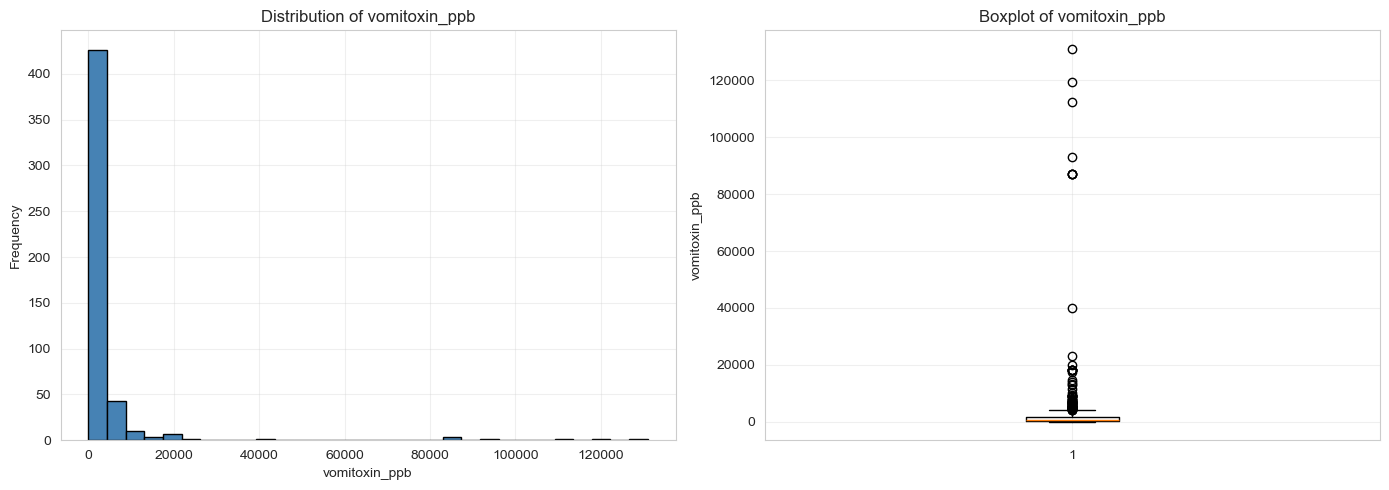

In [9]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df[target_col], bins=30, color='steelblue', edgecolor='black')
axes[0].set_xlabel(target_col)
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Distribution of {target_col}')
axes[0].grid(alpha=0.3)

# Boxplot
axes[1].boxplot(df[target_col], vert=True)
axes[1].set_ylabel(target_col)
axes[1].set_title(f'Boxplot of {target_col}')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Feature Analysis

In [10]:
# Separate features and target (drop ID column and target)
X = df.drop(columns=['hsi_id', target_col])
y = df[target_col]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (500, 448)
Target shape: (500,)


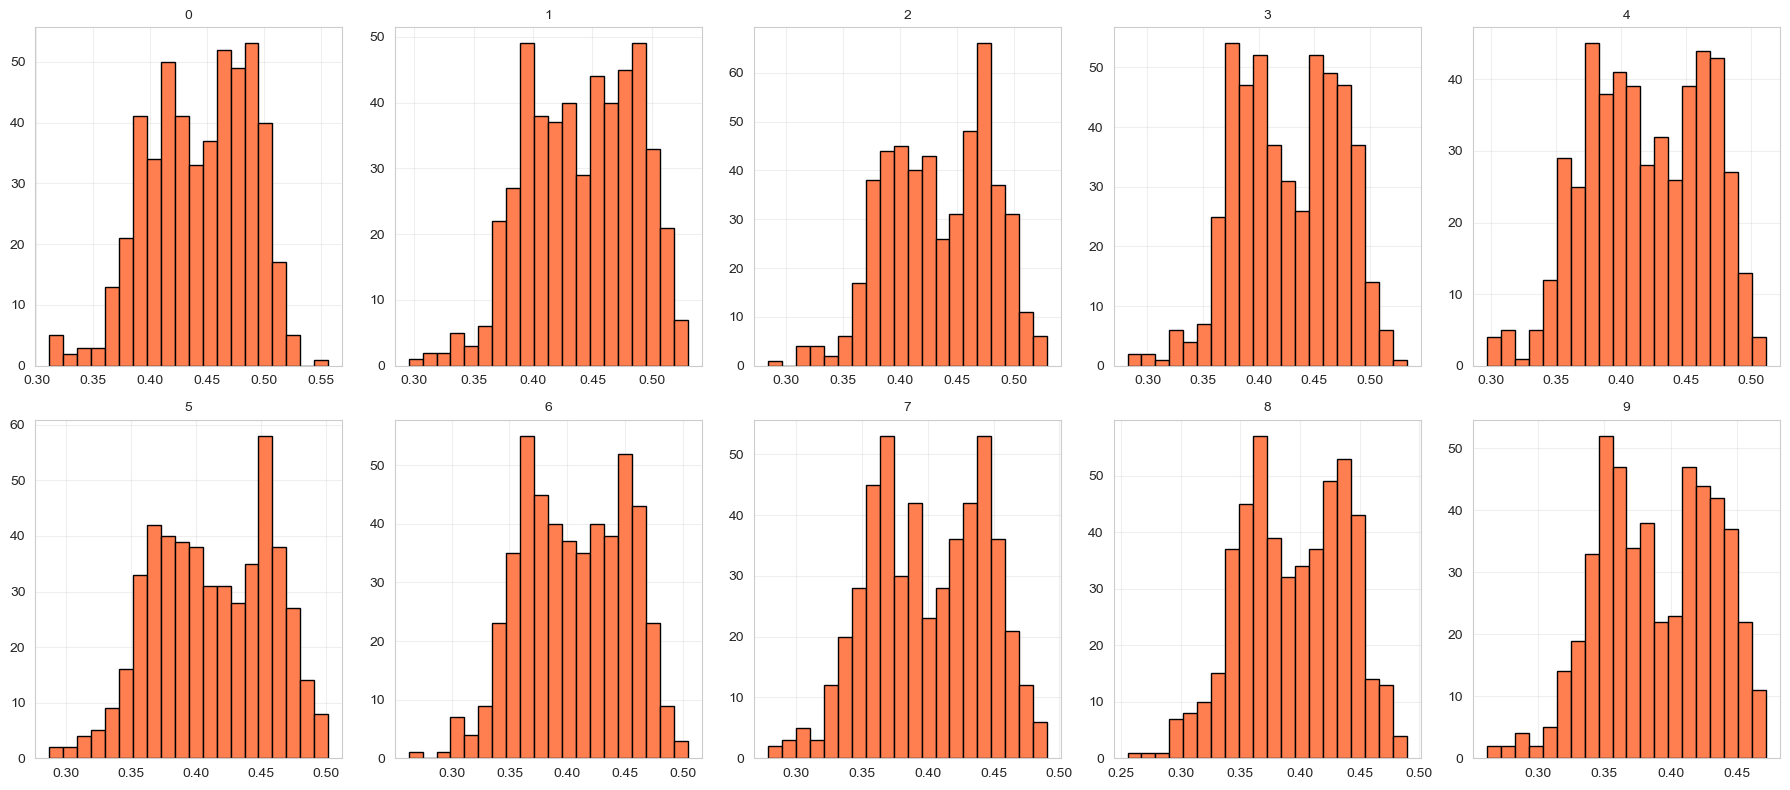

In [11]:
# Distribution of first 10 features
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(X.columns[:10]):
    axes[i].hist(X[col], bins=20, color='coral', edgecolor='black')
    axes[i].set_title(col, fontsize=10)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Spectral Signature Visualization

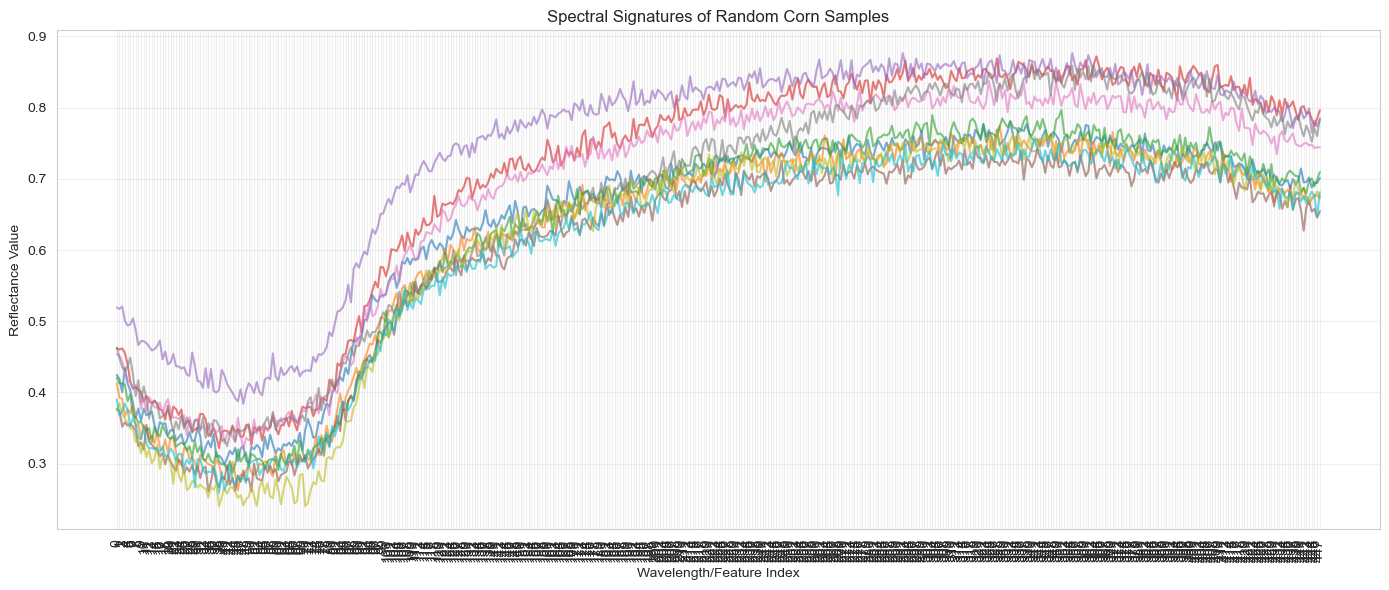

In [12]:
# Plot spectral signatures for random samples
sample_indices = np.random.choice(len(X), size=10, replace=False)

plt.figure(figsize=(14, 6))
for idx in sample_indices:
    # Filter out non-numeric columns before plotting
    numeric_columns = X.select_dtypes(include=[np.number]).columns
    x_values = [str(col) for col in numeric_columns]  # Use only numeric column names
    y_values = X.iloc[idx][numeric_columns].values.astype(float)  # Get only numeric values
    plt.plot(x_values, y_values, alpha=0.6, linewidth=1.5)

plt.xlabel('Wavelength/Feature Index')
plt.ylabel('Reflectance Value')
plt.title('Spectral Signatures of Random Corn Samples')
plt.xticks(rotation=90)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/spectral_signatures.png', dpi=300, bbox_inches='tight')
plt.show()

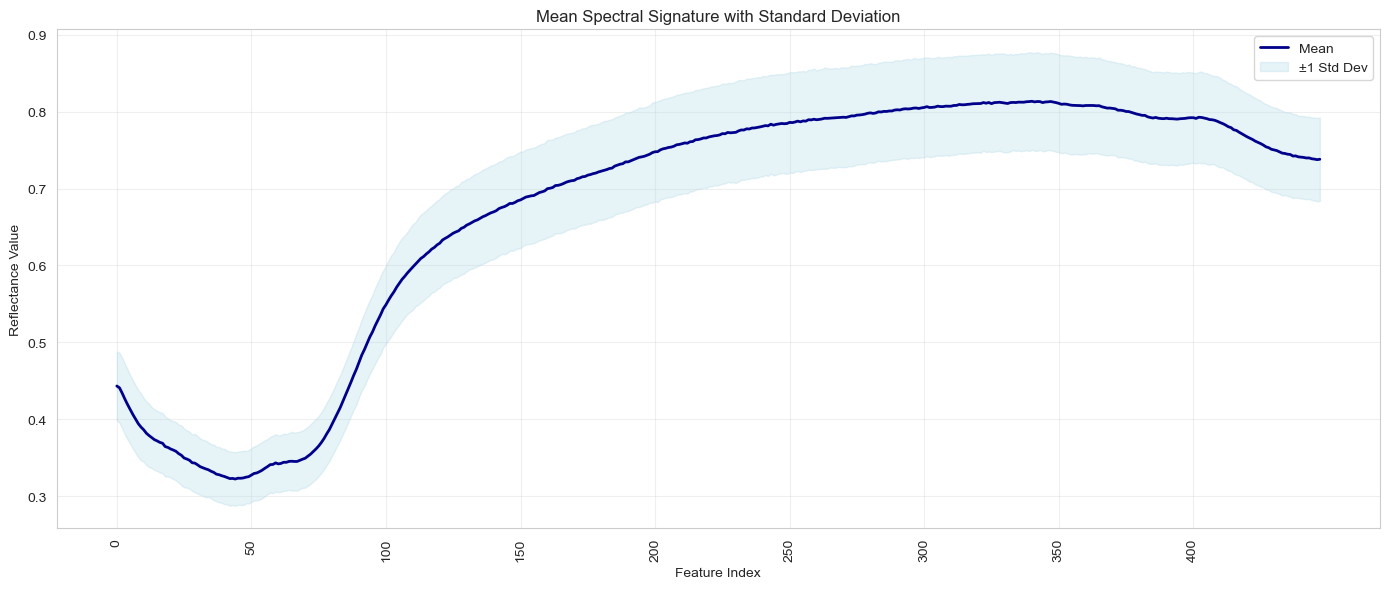

In [13]:
# Mean spectral signature
mean_spectrum = X.mean(axis=0)
std_spectrum = X.std(axis=0)

plt.figure(figsize=(14, 6))
# Use numeric indices instead of column names for x-axis
x_indices = range(len(X.columns))
plt.plot(x_indices, mean_spectrum, color='darkblue', linewidth=2, label='Mean')
plt.fill_between(x_indices, mean_spectrum - std_spectrum, mean_spectrum + std_spectrum, 
                 alpha=0.3, color='lightblue', label='±1 Std Dev')
plt.xlabel('Feature Index')  # Updated label to reflect numeric indices
plt.ylabel('Reflectance Value')
plt.title('Mean Spectral Signature with Standard Deviation')
# Set x-ticks to show only numeric indices, not column names
# Fixed: Use list() to convert range object and specify both positions and labels
tick_positions = list(x_indices)[::50]  # Convert range to list and get every 50th index
plt.xticks(tick_positions, tick_positions, rotation=90)  # Explicitly set both positions and labels as numeric
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/mean_spectral_signature.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Correlation Analysis

In [14]:
# Correlation with target
correlations = X.corrwith(y).sort_values(ascending=False)
print("Top 10 features correlated with target:")
print(correlations.head(10))
print("\nBottom 10 features correlated with target:")
print(correlations.tail(10))

Top 10 features correlated with target:
71    0.104296
67    0.096542
70    0.095694
48    0.092803
50    0.092493
47    0.090392
69    0.089803
64    0.088663
66    0.088143
68    0.083566
dtype: float64

Bottom 10 features correlated with target:
129   -0.298195
139   -0.298224
152   -0.298384
120   -0.299075
146   -0.300369
149   -0.300649
143   -0.302372
127   -0.303796
135   -0.307941
140   -0.313444
dtype: float64


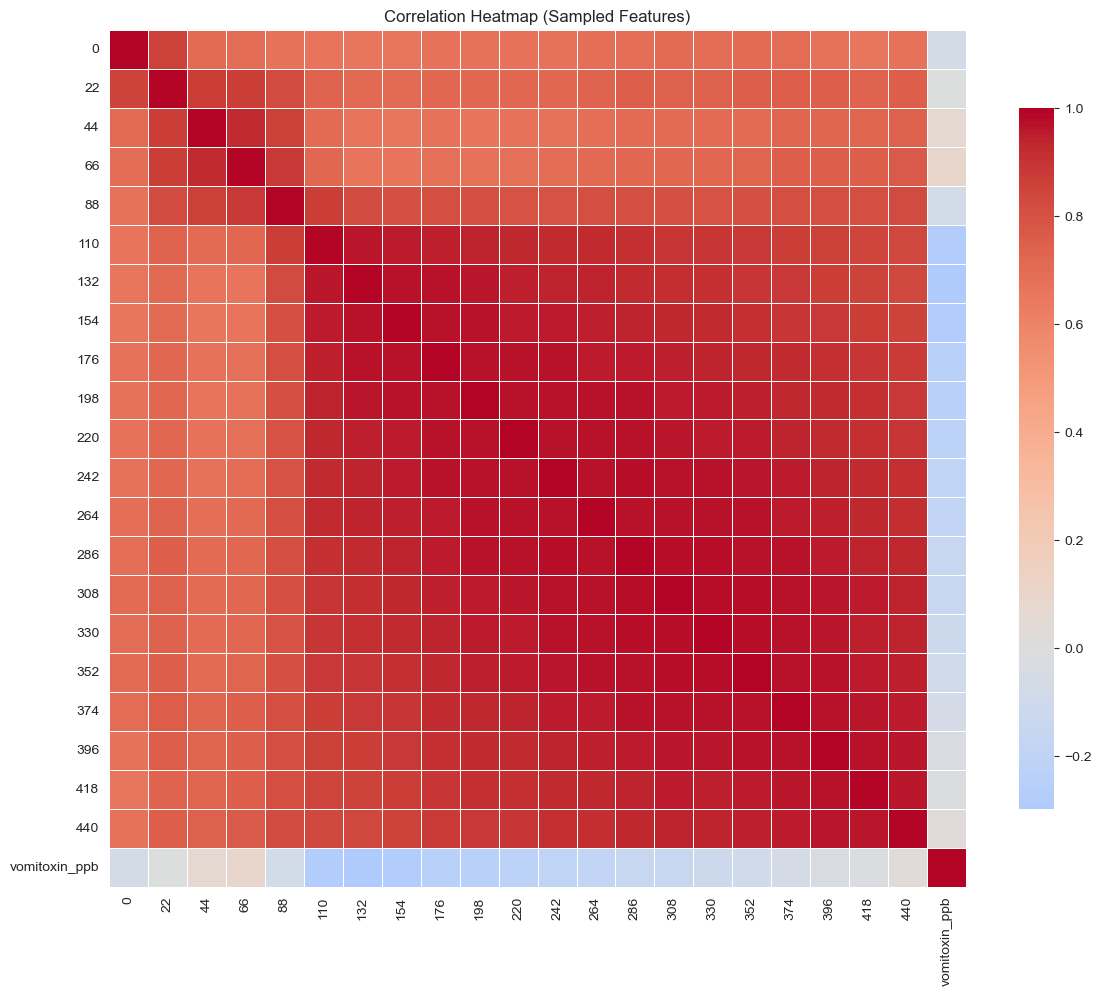

In [15]:
# Correlation heatmap (sample of features)
sample_features = X.columns[::max(1, len(X.columns)//20)]  # Sample every nth feature
corr_matrix = df[list(sample_features) + [target_col]].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap (Sampled Features)')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Outlier Detection

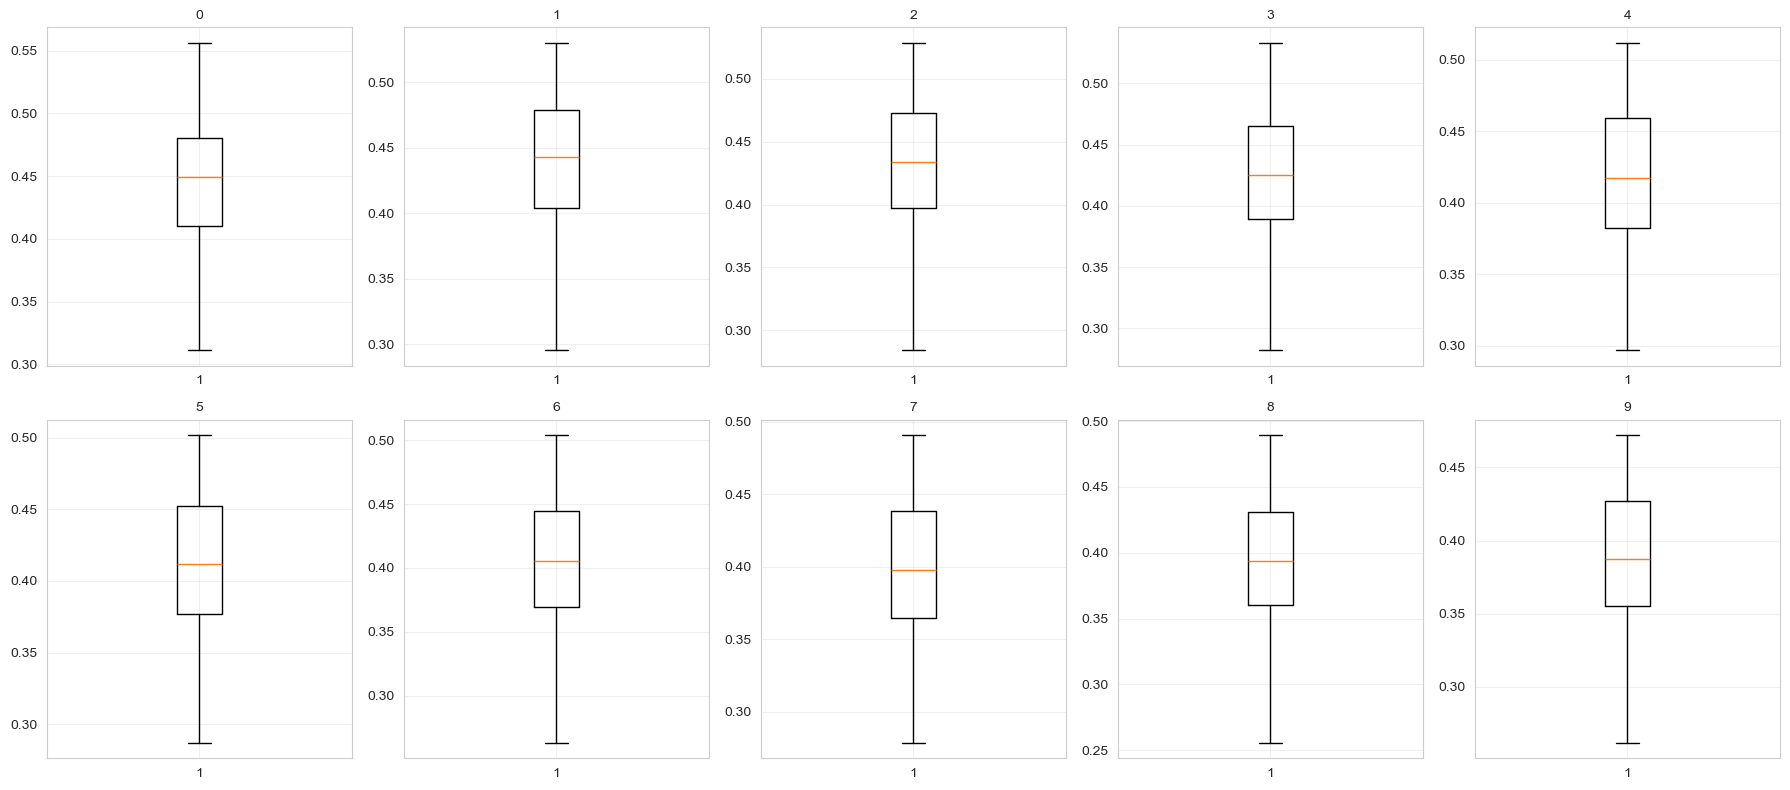

In [16]:
# Boxplot for sample features
sample_cols = X.columns[:10]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(sample_cols):
    axes[i].boxplot(X[col])
    axes[i].set_title(col, fontsize=10)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/outlier_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# Z-score based outlier detection
from scipy import stats

z_scores = np.abs(stats.zscore(X))
outlier_rows = (z_scores > 3).any(axis=1)
print(f"Number of rows with outliers (Z-score > 3): {outlier_rows.sum()}")
print(f"Percentage: {(outlier_rows.sum() / len(X)) * 100:.2f}%")

Number of rows with outliers (Z-score > 3): 29
Percentage: 5.80%


## 10. Data Preprocessing

In [18]:
# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (400, 448)
Test set size: (100, 448)


In [19]:
# Feature scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("✓ Feature scaling completed!")

✓ Feature scaling completed!


In [20]:
# Verify scaling
print("Before Scaling:")
print(X_train.describe().loc[['mean', 'std']].T.head())
print("\nAfter Scaling:")
print(X_train_scaled.describe().loc[['mean', 'std']].T.head())

Before Scaling:
       mean       std
0  0.443735  0.044289
1  0.441284  0.044979
2  0.434927  0.045814
3  0.426931  0.045755
4  0.419851  0.044894

After Scaling:
           mean       std
0 -1.998401e-16  1.001252
1 -1.831868e-16  1.001252
2 -2.553513e-16  1.001252
3 -7.027712e-16  1.001252
4 -1.056932e-15  1.001252


## 11. Save Processed Data

In [21]:
# Save processed datasets
X_train_scaled.to_csv('../data/X_train_scaled.csv', index=False)
X_test_scaled.to_csv('../data/X_test_scaled.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)

print("✓ All processed datasets saved successfully!")
print("\nSaved files:")
print("  - X_train_scaled.csv")
print("  - X_test_scaled.csv")
print("  - y_train.csv")
print("  - y_test.csv")

✓ All processed datasets saved successfully!

Saved files:
  - X_train_scaled.csv
  - X_test_scaled.csv
  - y_train.csv
  - y_test.csv


## 12. Summary

In [22]:
print("="*60)
print("NOTEBOOK 1: EDA & PREPROCESSING - COMPLETED")
print("="*60)
print(f"\n✓ Dataset loaded: {df.shape[0]} samples, {df.shape[1]} columns")
print(f"✓ Missing values: {df.isnull().sum().sum()}")
print(f"✓ Duplicates removed: {duplicates}")
print(f"✓ Train-test split: 80-20")
print(f"✓ Feature scaling: StandardScaler applied")
print(f"✓ Visualizations saved: 6 plots")
print(f"✓ Processed data saved for next notebook")
print("\n" + "="*60)
print("Ready for Notebook 2: Dimensionality Reduction")
print("="*60)

NOTEBOOK 1: EDA & PREPROCESSING - COMPLETED

✓ Dataset loaded: 500 samples, 450 columns
✓ Missing values: 0
✓ Duplicates removed: 0
✓ Train-test split: 80-20
✓ Feature scaling: StandardScaler applied
✓ Visualizations saved: 6 plots
✓ Processed data saved for next notebook

Ready for Notebook 2: Dimensionality Reduction
